# Quality Control Plotting

In [1]:
here::i_am("01_paper_QC.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/01_Eomes_RNA/code



In [2]:
io$basedir

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/01_Eomes_RNA"

In [3]:
args = list()
args$meta = file.path(io$basedir, 'results/rna/doublet_detection/sample_metadata_after_doublets.txt.gz')
args$sce = io$rna.sce

In [4]:
summary(names(opts$sample2pool) == names(opts$sample2tomato))

   Mode    TRUE 
logical       8 

In [6]:
sample_rename = paste0(opts$sample2pool, '_', ifelse(opts$sample2tomato == TRUE, 'KO', 'WT'))
names(sample_rename) = names(opts$sample2pool)

sample_colors = c(
    'pool1_KO' = '#8B0000',
    'pool1_WT' = '#000000',
    'pool2_KO' = '#B10000',
    'pool2_WT' = '#4C4C4C',
    'pool3_KO' = '#D80000',
    'pool3_WT' = '#989898',
    'pool4_KO' = '#FF0000',
    'pool4_WT' = '#E5E5E5'
)

In [7]:
black_palette <- colorRampPalette(c("black", "gray90"))(4)  # 5 shades of black
red_palette <- colorRampPalette(c("red4", "red"))(4)       # 3 shades of red

# Combine the palettes
custom_palette <- c(black_palette, red_palette)

# Print the custom palette
print(custom_palette)

[1] "#000000" "#4C4C4C" "#989898" "#E5E5E5" "#8B0000" "#B10000" "#D80000"
[8] "#FF0000"


In [8]:
meta <- fread(args$meta) %>% 
  .[pass_rnaQC==TRUE & doublet_call==FALSE]  %>% 
    .[,sample_clean := factor(sample_rename[match(sample, names(sample_rename))], levels = sample_rename[order(sample_rename)])]

In [9]:
# Define a custom theme
theme = theme(
  # axis.title = element_text(color = 'black', size = 7),
  axis.title = element_blank(),
  axis.text.x = element_text(angle=90, hjust=1, vjust=0.5, size=5, color = 'black'), 
  axis.text = element_text(size=5, color='black'),
  text = element_text(size=5),
  plot.margin = margin(0, 3, 0, 0),  # Adjust the margin around the plot
  plot.title = element_text(size=7, face='plain', hjust=0.5, vjust = -0.5),
  panel.border = element_rect(color='black', linewidth=0.5, fill = NA),
  panel.background = element_blank(),
  panel.grid.major = element_line(color = 'grey95'),
  axis.line = element_blank(),
  axis.ticks = element_line(linewidth=0.25, color = 'black'),
  legend.position = 'none'
)

# Create a list of common geoms
geoms <- list(
  geom_violin(linewidth = 0.1, aes(fill = sample_clean)),
  geom_boxplot(width = 0.2, linewidth = 0.1, outlier.shape = NA, fill = 'white'),
  scale_fill_manual(values = sample_colors) 
)

p_rna_reads = ggplot(meta, aes(sample_clean, log(nCount_RNA))) + 
    geoms + 
    ggtitle('Log(# counts)') + 
    theme

p_rna_genes = ggplot(meta, aes(sample_clean, log(nFeature_RNA))) + 
    geoms + 
    ggtitle('Log(# genes)') + 
    theme

p_rna_ribo = ggplot(meta, aes(sample_clean, ribosomal_percent_RNA)) + 
    geoms + 
    ggtitle('% Ribo counts') + 
    theme

p_rna_mito = ggplot(meta, aes(sample_clean, mitochondrial_percent_RNA)) + 
    geoms + 
    ggtitle('% Mito counts') + 
    theme

options(repr.plot.height=7, repr.plot.width=25)
p1 = ggarrange(p_rna_reads, p_rna_genes, p_rna_mito, p_rna_ribo, nrow = 1, align = 'hv')


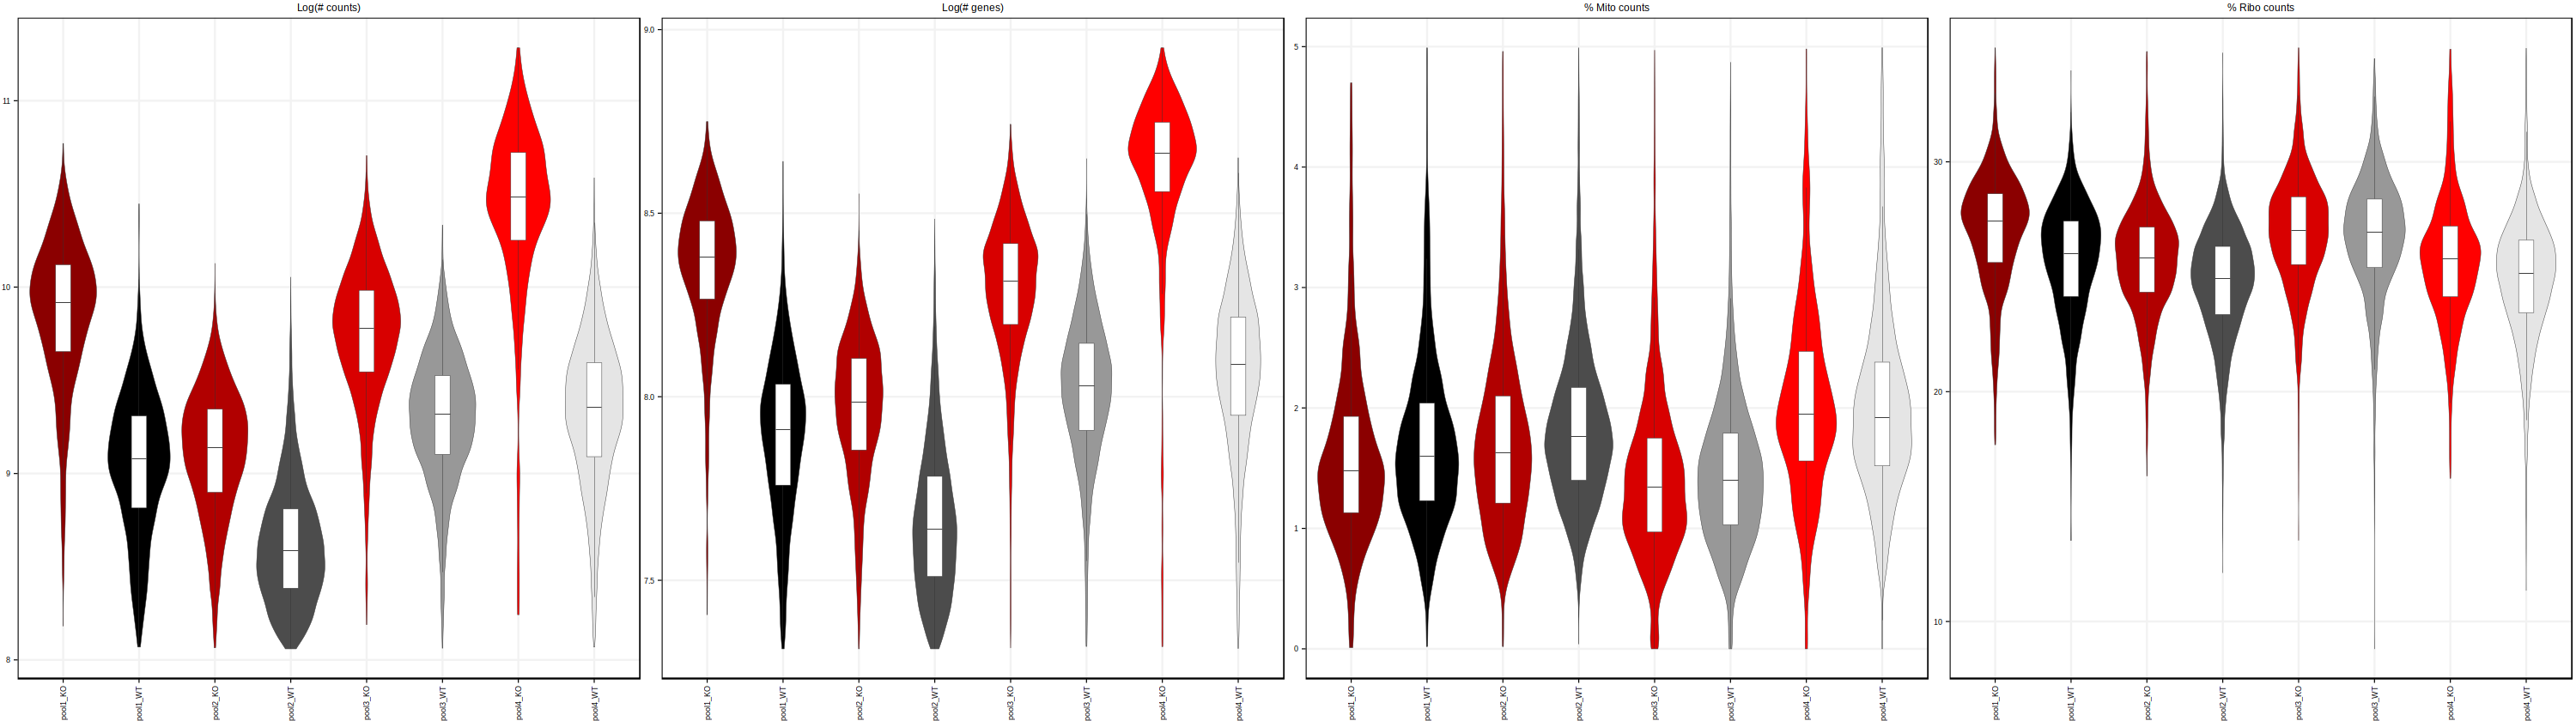

In [10]:
p1

In [39]:
ggsave(file.path(io$basedir, 'figures/Eomes_chimera_QC_metrics.pdf'), 
       plot = p1,
       width = 115, 
       height = 40, 
       units = "mm")

In [25]:
# Define a custom theme
theme = theme(
  # axis.title = element_text(color = 'black', size = 7),
  axis.title = element_blank(),
  axis.text.x = element_text(angle=90, hjust=1, vjust=0.5, size=5, color = 'black'), 
  axis.text = element_text(size=5, color='black'),
  text = element_text(size=5),
  plot.margin = margin(0, 3, 0, 0),  # Adjust the margin around the plot
  plot.title = element_text(size=7, face='plain', hjust=0.5, vjust = -0.5),
  panel.border = element_rect(color='black', linewidth=0.5, fill = NA),
  panel.background = element_blank(),
  panel.grid.major = element_line(color = 'grey95'),
  axis.line = element_blank(),
  axis.ticks = element_line(linewidth=0.25, color = 'black'),
  legend.position = 'none'
)

# Create a list of common geoms
geoms <- list(
  geom_violin(linewidth = 0.1, aes(fill = sample_clean)),
  geom_boxplot(width = 0.2, linewidth = 0.1, outlier.shape = NA, fill = 'white'),
  scale_fill_manual(values = sample_colors) 
)

p_rna_reads = ggplot(meta, aes(sample_clean, log(nCount_RNA))) + 
    scale_y_continuous(limits = c(0, max(log(meta$nCount_RNA))), expand = c(0,0,0.05,0)) + 
    geoms + 
    ggtitle('Log(# counts)') + 
    theme

p_rna_genes = ggplot(meta, aes(sample_clean, log(nFeature_RNA))) + 
    scale_y_continuous(limits = c(0, max(log(meta$nFeature_RNA))), expand = c(0,0,0.05,0)) + 
    geoms + 
    ggtitle('Log(# genes)') + 
    theme

p_rna_ribo = ggplot(meta, aes(sample_clean, ribosomal_percent_RNA)) + 
    scale_y_continuous(limits = c(0, max(meta$ribosomal_percent_RNA)), expand = c(0,0,0.05,0)) + 
    geoms + 
    ggtitle('% Ribo counts') + 
    theme

p_rna_mito = ggplot(meta, aes(sample_clean, mitochondrial_percent_RNA)) + 
    scale_y_continuous(limits = c(0, max(meta$mitochondrial_percent_RNA)), expand = c(0,0,0.05,0)) + 
    geoms + 
    ggtitle('% Mito counts') + 
    theme

options(repr.plot.height=7, repr.plot.width=25)
p1 = ggarrange(p_rna_reads, p_rna_genes, p_rna_mito, p_rna_ribo, nrow = 1, align = 'hv')


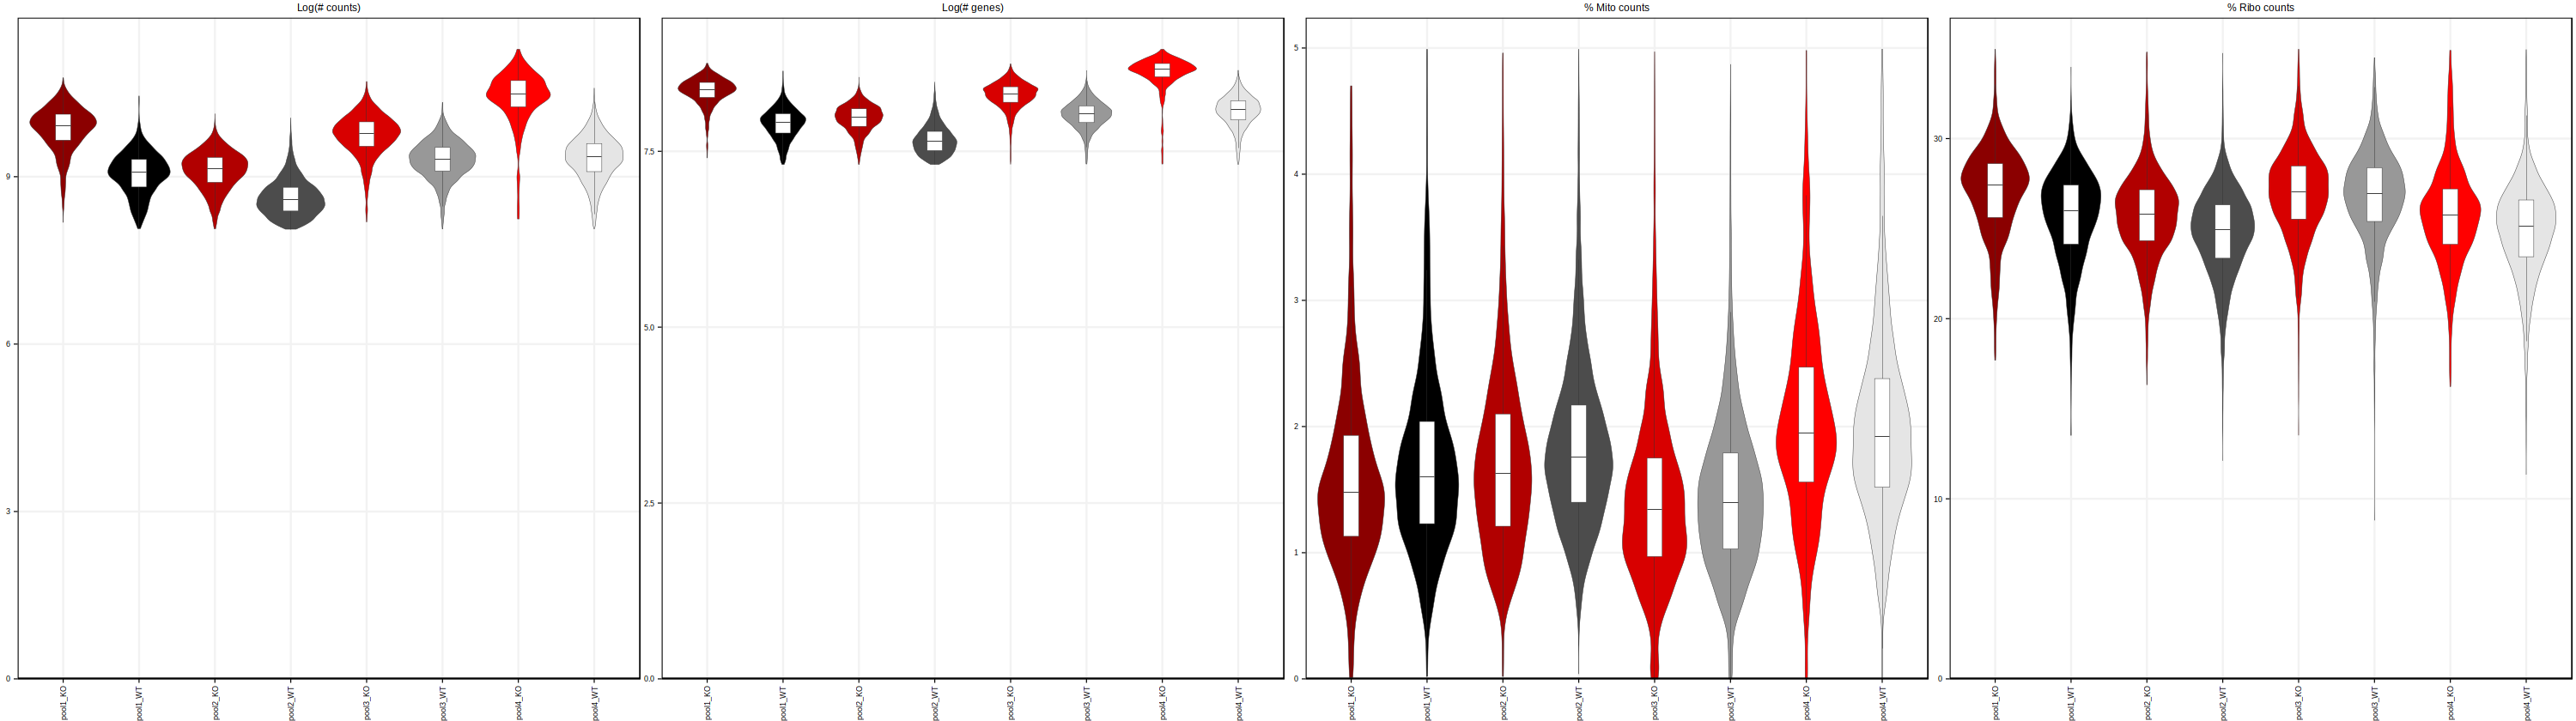

In [26]:
p1

In [27]:
ggsave(file.path(io$basedir, 'figures/Eomes_chimera_QC_metrics_revision.pdf'), 
       plot = p1,
       width = 115, 
       height = 40, 
       units = "mm")

In [22]:
meta_atlas <- fread(io$rna.atlas.metadata) %>% 
    .[, sample_clean := as.factor(sample)]

In [24]:
p1 = ggplot(meta_atlas, aes(sample_clean, log(nCount_RNA))) + 
    geoms + 
    ylim(0, 12) + 
    ggtitle('Log(# counts)') + 
    theme

p2 = ggplot(meta_atlas, aes(sample_clean, log(nFeature_RNA))) + 
    geoms + 
    ylim(0, 9) + 
    ggtitle('Log(# genes)') + 
    theme

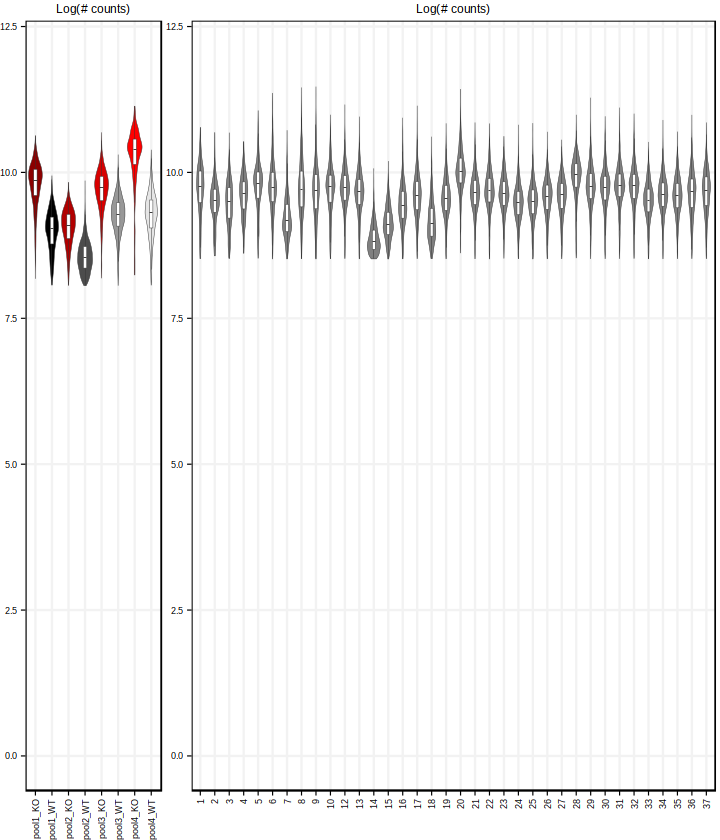

In [47]:
options(repr.plot.height=7, repr.plot.width=6)
ggarrange(p_rna_reads, p1, nrow = 1, widths = c(0.3, 1), align = 'hv')

In [33]:
meta = meta %>% 
    .[, pool := opts$sample2pool[match(sample, names(opts$sample2pool))]]

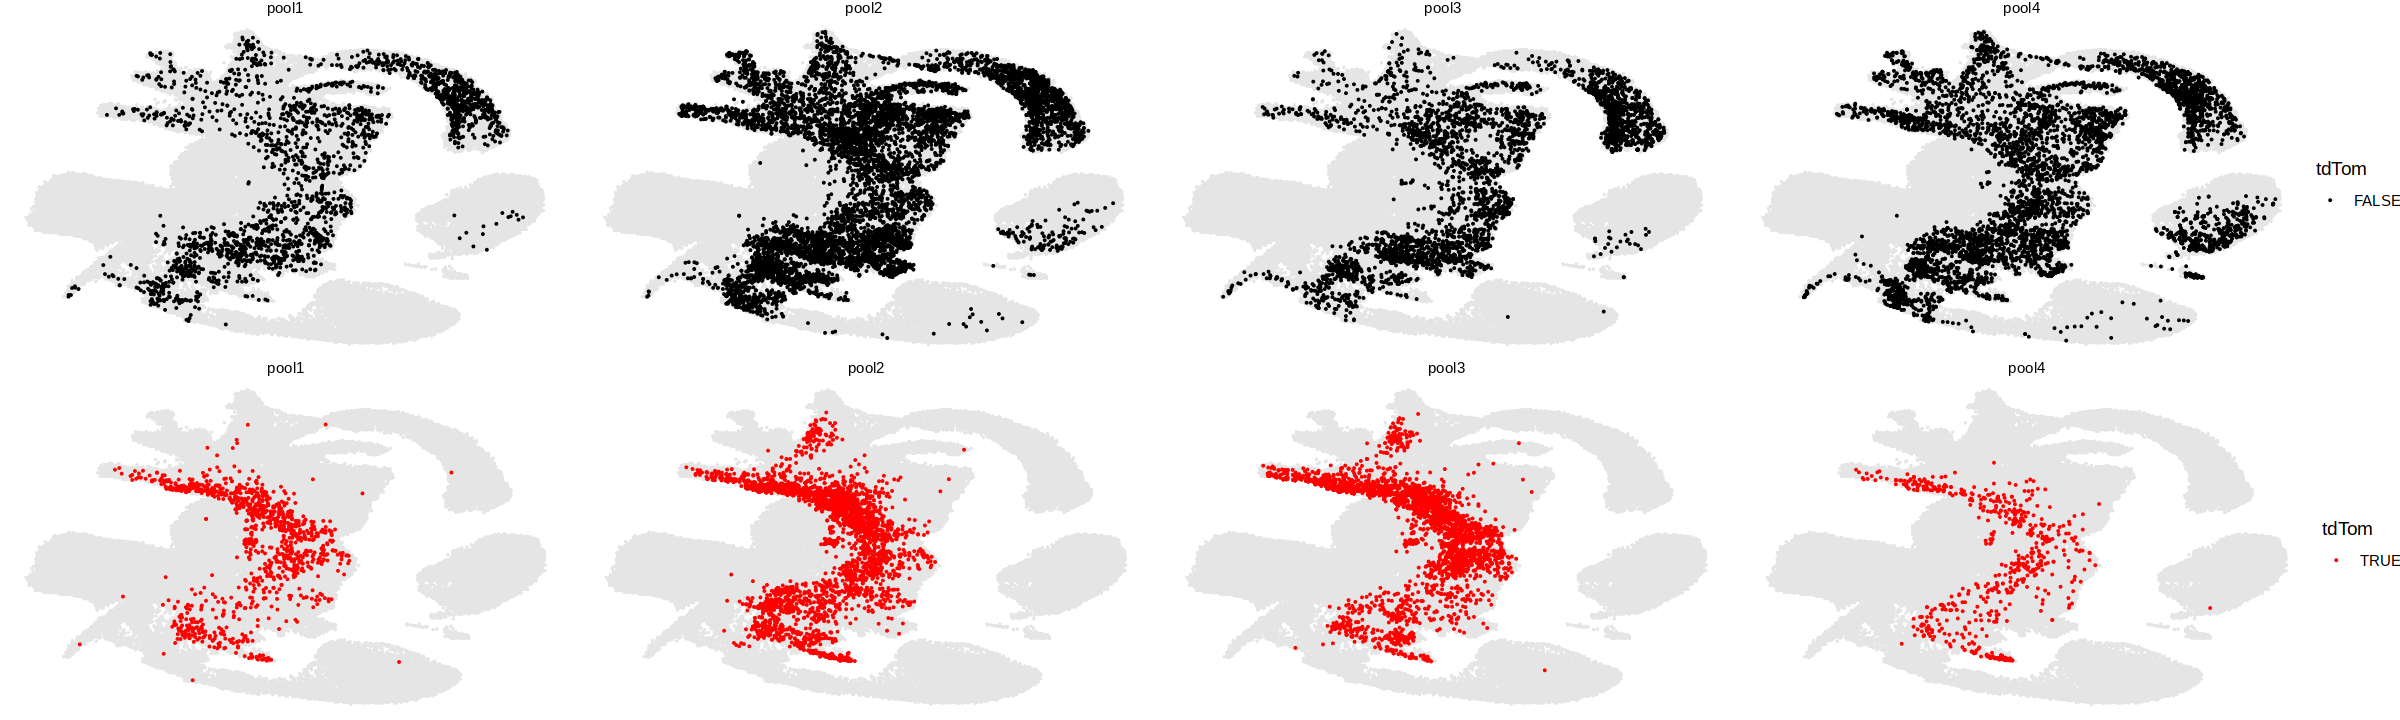

In [44]:
options(repr.plot.height=6, repr.plot.width=20)

ggarrange(ggplot(meta[tdTom == FALSE], aes(umapX, umapY, color = tdTom)) + 
        ggrastr::geom_point_rast(data = meta_atlas, color = 'grey90', size = 0.1) + 
        geom_point(size = 0.05) + 
        scale_color_manual(values = opts$tdTom.color) + 
        facet_wrap(~pool, nrow = 1) + 
        theme_void(),
    ggplot(meta[tdTom == TRUE], aes(umapX, umapY, color = tdTom)) + 
        ggrastr::geom_point_rast(data = meta_atlas, color = 'grey90', size = 0.1) + 
        geom_point(size = 0.05) + 
        scale_color_manual(values = opts$tdTom.color) + 
        facet_wrap(~pool, nrow = 1) + 
        theme_void(),
    nrow = 2)

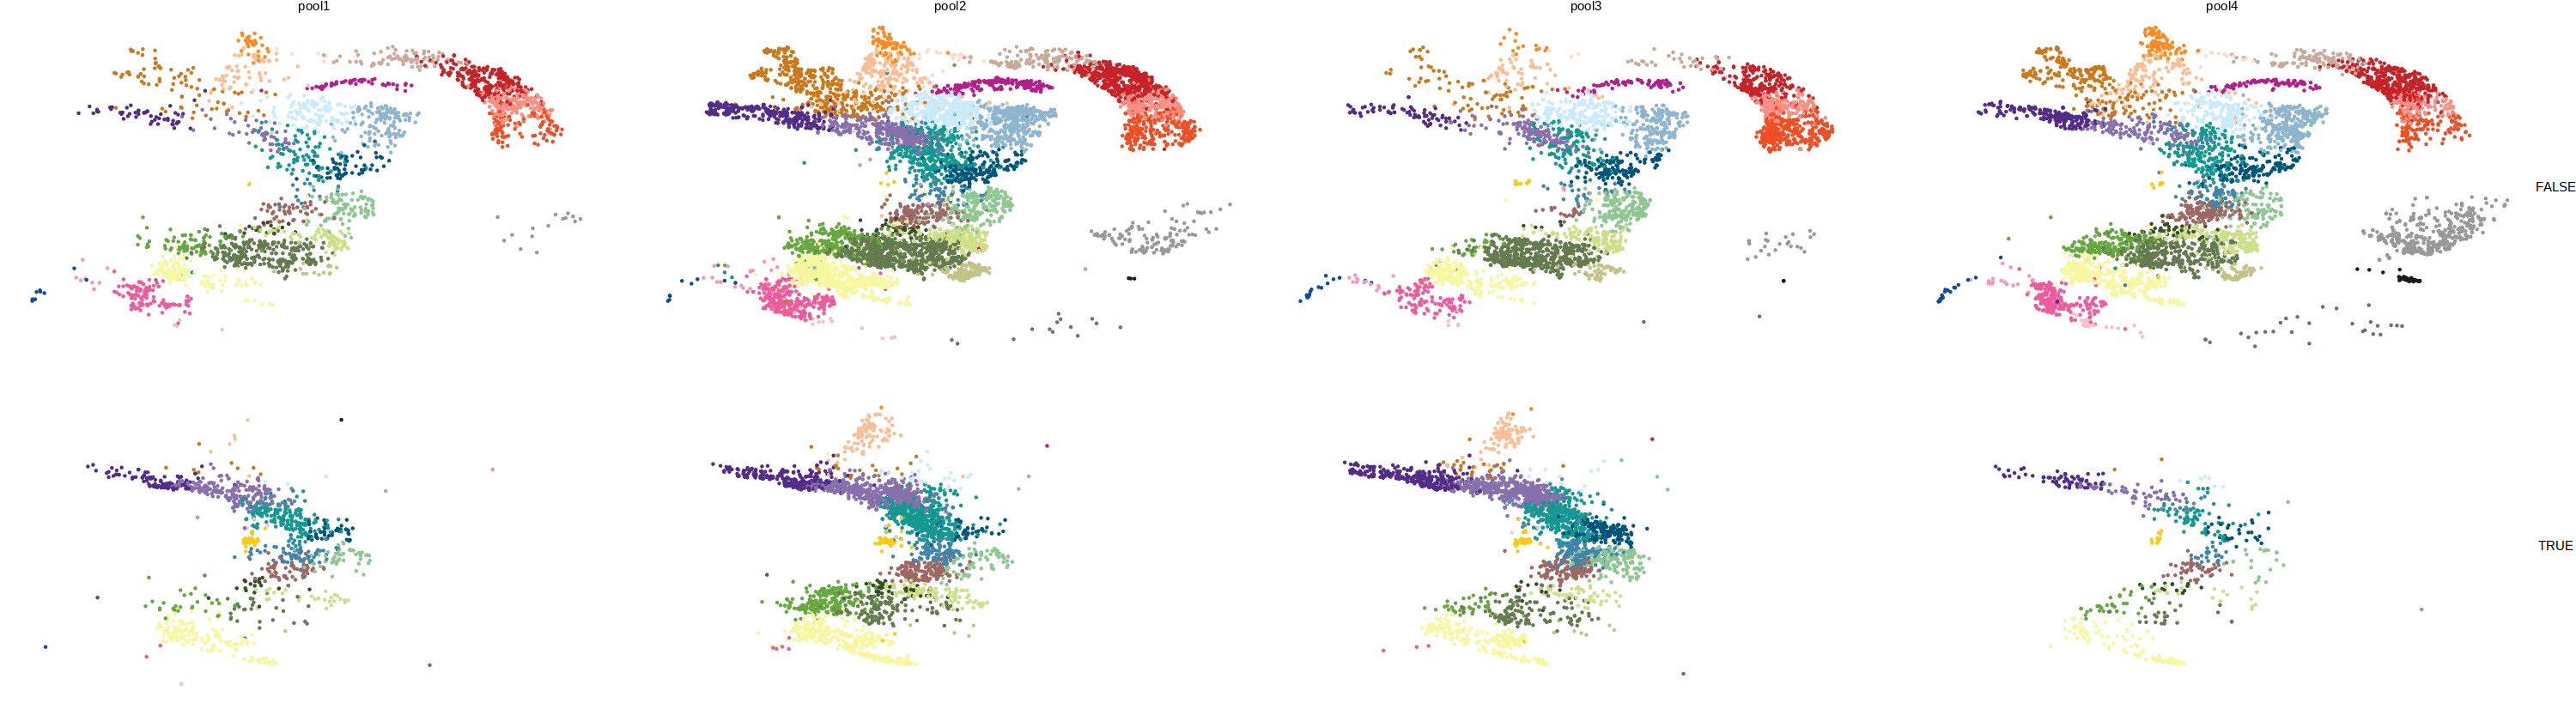

In [37]:
ggplot(meta, aes(umapX, umapY, color = celltype.mapped_mnn)) + 
    geom_point(size = 0.2) + 
    scale_color_manual(values = opts$celltype.colors) + 
    facet_grid(tdTom ~ pool) + 
    theme_void() + 
    theme(
        legend.position = 'below'
        )

In [38]:
table(meta$pool, meta$tdTom)

       
        FALSE TRUE
  pool1  2414 1153
  pool2  8133 3465
  pool3  3791 3346
  pool4  5819  602

In [40]:
table(meta$sample, meta$tdTom)

                             
                              FALSE TRUE
  SLX-20795_SITTA11_HKTG2DRXY     0  602
  SLX-20795_SITTA12_HKTG2DRXY  2414    0
  SLX-20795_SITTB11_HKTG2DRXY  5819    0
  SLX-20795_SITTF11_HKTG2DRXY     0 3346
  SLX-20795_SITTG10_HKTG2DRXY     0 3465
  SLX-20795_SITTG11_HKTG2DRXY  3791    0
  SLX-20795_SITTH10_HKTG2DRXY  8133    0
  SLX-20795_SITTH11_HKTG2DRXY     0 1153

In [31]:
library(MouseGastrulationData)

Loading required package: SpatialExperiment



In [28]:
Tal1_Data = MouseGastrulationData::Tal1ChimeraData()

snapshotDate(): 2022-10-31

see ?MouseGastrulationData and browseVignettes('MouseGastrulationData') for documentation

loading from cache

see ?MouseGastrulationData and browseVignettes('MouseGastrulationData') for documentation

loading from cache

see ?MouseGastrulationData and browseVignettes('MouseGastrulationData') for documentation

loading from cache

see ?MouseGastrulationData and browseVignettes('MouseGastrulationData') for documentation

loading from cache



In [39]:
tal1_meta = as.data.table(colData(Tal1_Data)) %>% 
    .[, nReads := colSums(counts(Tal1_Data))]

In [43]:
unique(tal1_meta$sample)

[1] 1 2 3 4

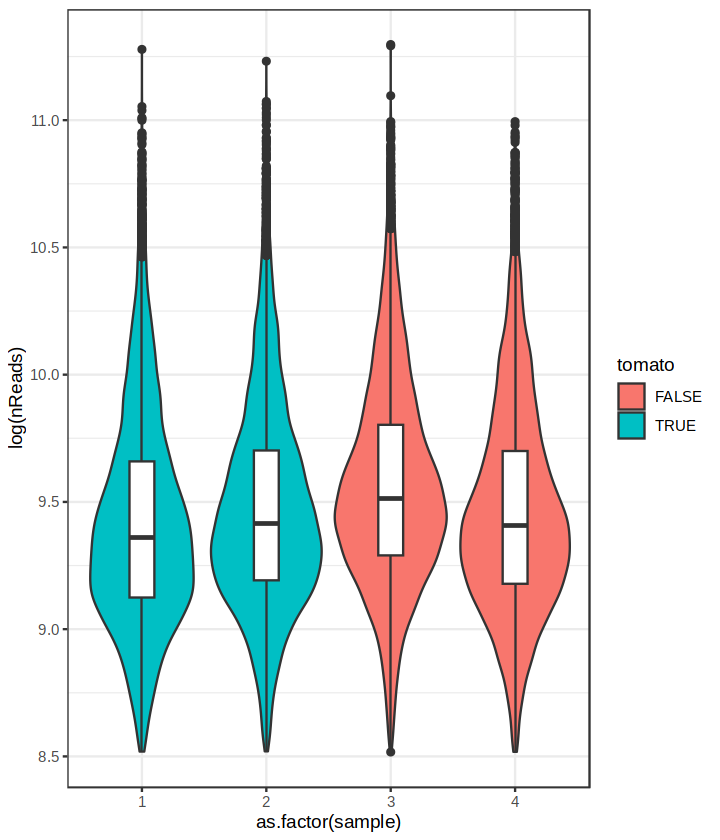

In [45]:
ggplot(tal1_meta, aes(as.factor(sample), log(nReads), fill = tomato)) + 
    geom_violin() + 
    geom_boxplot(fill = 'white', width = 0.2) + 
    theme_bw()

In [15]:
sample_rename = paste0(opts$sample2pool, '_', ifelse(opts$sample2tomato == TRUE, 'KO', 'WT'))
names(sample_rename) = names(opts$sample2pool)

sample_colors = c(
    'pool1_KO' = '#8B0000',
    'pool1_WT' = '#000000',
    'pool2_KO' = '#B10000',
    'pool2_WT' = '#4C4C4C',
    'pool3_KO' = '#D80000',
    'pool3_WT' = '#989898',
    'pool4_KO' = '#FF0000',
    'pool4_WT' = '#E5E5E5'
)

In [16]:
black_palette <- colorRampPalette(c("black", "gray90"))(4)  # 5 shades of black
red_palette <- colorRampPalette(c("red4", "red"))(4)       # 3 shades of red

# Combine the palettes
custom_palette <- c(black_palette, red_palette)

# Print the custom palette
print(custom_palette)

[1] "#000000" "#4C4C4C" "#989898" "#E5E5E5" "#8B0000" "#B10000" "#D80000"
[8] "#FF0000"


In [17]:
meta <- tal1_meta  %>% 
    .[,sample_clean := factor(sample_rename[match(sample, names(sample_rename))], levels = sample_rename[order(sample_rename)])]

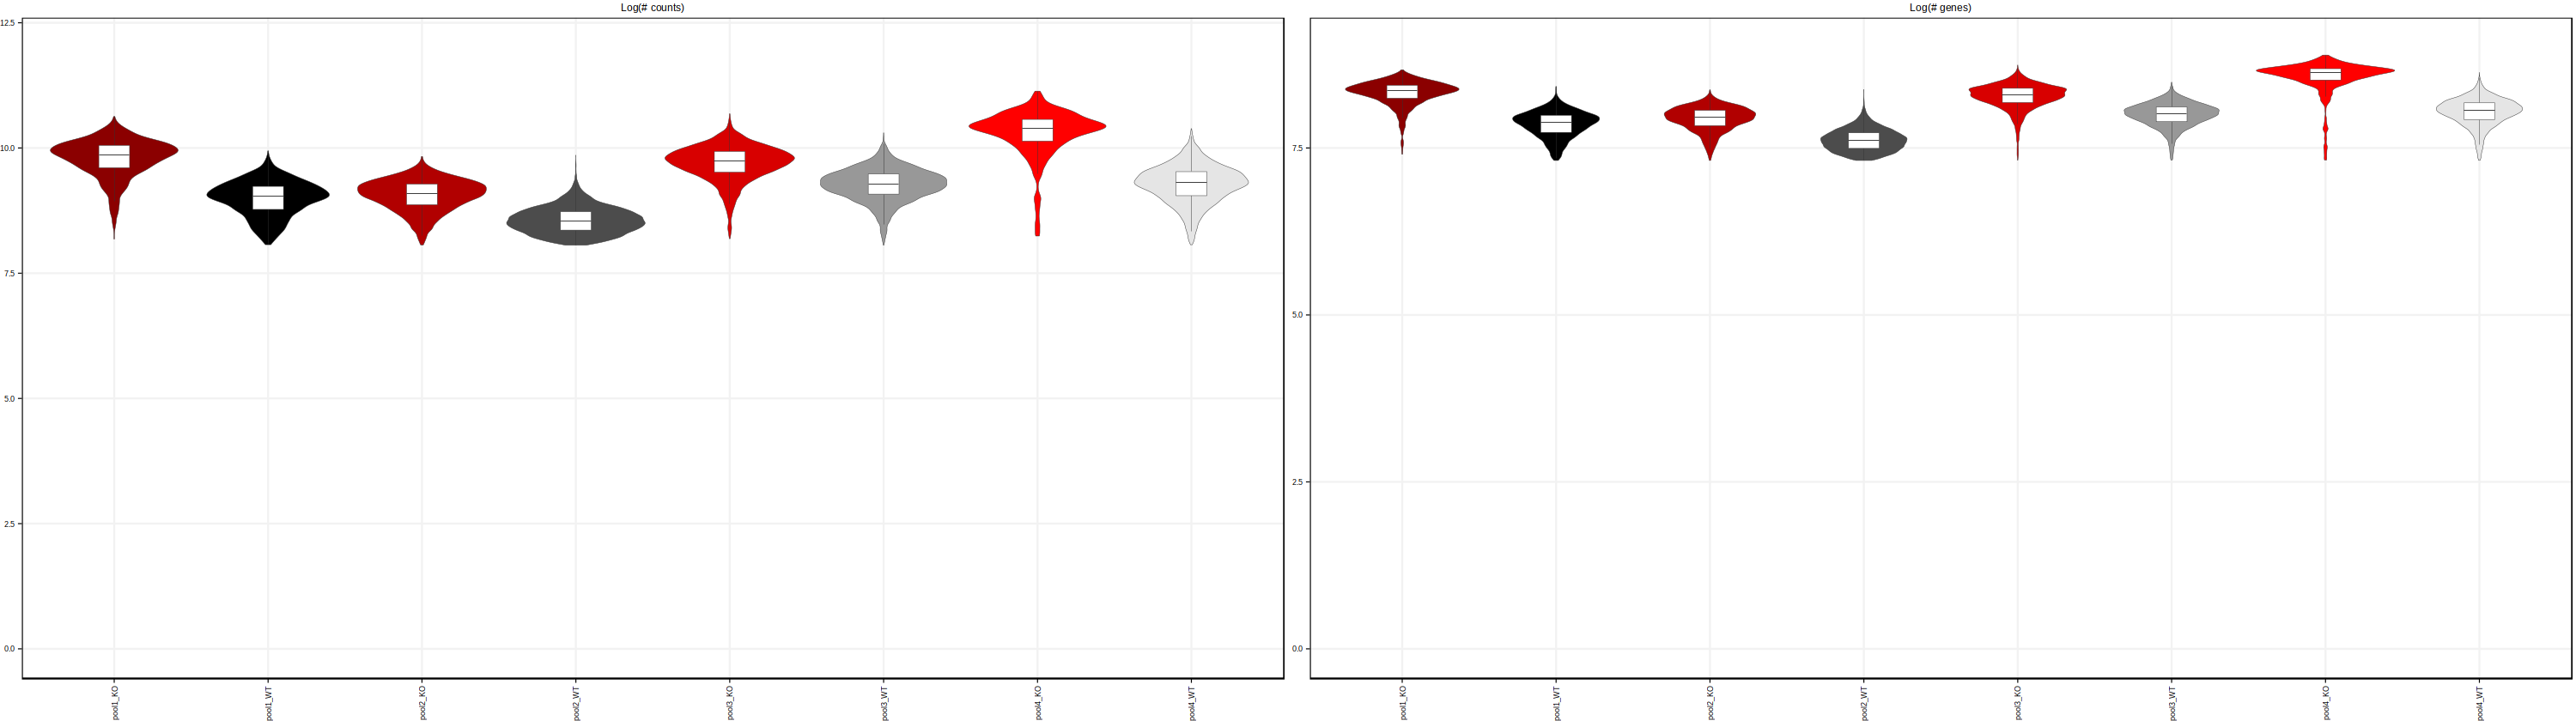

In [18]:
# Define a custom theme
theme = theme(
  # axis.title = element_text(color = 'black', size = 7),
  axis.title = element_blank(),
  axis.text.x = element_text(angle=90, hjust=1, vjust=0.5, size=5, color = 'black'), 
  axis.text = element_text(size=5, color='black'),
  text = element_text(size=5),
  plot.margin = margin(0, 3, 0, 0),  # Adjust the margin around the plot
  plot.title = element_text(size=7, face='plain', hjust=0.5, vjust = -0.5),
  panel.border = element_rect(color='black', linewidth=0.5, fill = NA),
  panel.background = element_blank(),
  panel.grid.major = element_line(color = 'grey95'),
  axis.line = element_blank(),
  axis.ticks = element_line(linewidth=0.25, color = 'black'),
  legend.position = 'none'
)

# Create a list of common geoms
geoms <- list(
  geom_violin(linewidth = 0.1, aes(fill = sample_clean)),
  geom_boxplot(width = 0.2, linewidth = 0.1, outlier.shape = NA, fill = 'white'),
  scale_fill_manual(values = sample_colors) 
)

p_rna_reads = ggplot(meta, aes(sample_clean, log(nCount_RNA))) + 
    geoms + 
    ylim(0, 12) + 
    ggtitle('Log(# counts)') + 
    theme

p_rna_genes = ggplot(meta, aes(sample_clean, log(nFeature_RNA))) + 
    geoms + 
    ylim(0, 9) + 
    ggtitle('Log(# genes)') + 
    theme

options(repr.plot.height=7, repr.plot.width=25)
p1 = ggarrange(p_rna_reads, p_rna_genes, nrow = 1, align = 'hv')
p1